### 1. Dependencies

In [271]:
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import univariate_portfolio_sorting, conditional_pct_change, standardize_pivot, low_high
from functions.data_functions.get_data import get_row_universe, get_usa_universe, get_processed_fx_rates, get_famafrench_factors

In [272]:
# MANUAL INPUT
download_wrds_data = False#True
download_ff_data = False#True
esg_choice = 'none'               # 's&p' or 'refinitiv' or 'none'
start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2023

#sector split
even_split_no = 12
no_simple_quantiles = 6

# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

Golden Data

In [273]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"

# Golden Dataset
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')
lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')

Filters

In [274]:
#currencies we keep
currency_filter = ['EUR', 'USD'] #['CHF', 'GBP', 'EUR', 'USD'])]
# region_filter = ["United States and Canada"]



execute_location_filters = False
loc_filter = ["USA"]


Filter_RealEstate_and_Financials = False
drop_real_estate = True


### 2. Data

#### 2.1 LC dataset

In [275]:
lc.dropna(subset=['gvkey'], inplace=True)

# Change types to align with WRDS
lc['gvkey'] = lc['gvkey'].astype(int).astype(str)
lc['rfyear'] = lc['rfyear'].astype('Int64')

# Keep rows with some minimum information
lc = lc.dropna(subset=['gvkey', 'rfyear', 'loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3'])

# Filter rows where MacroRegion is in the specified list
regions = ["Asia-Pacific", "Europe", "United States and Canada"]
lc = lc[lc['MacroRegion'].isin(regions)]

# Filter data to keep observatios from `start_year`
lc = lc[lc['rfyear'] >= start_year]
lc = lc[lc['rfyear'] <= end_year]

def map_sectors(x):
    # Skip Industrials, Health Care, Utilities
    if x in ['Energy', 'Materials']:
        return 'Primary Industries'
    elif x in ['Consumer Discretionary', 'Consumer Staples']:
        return 'Consumer'

    # make Financial = Financials if you want to include finance sector
    elif x in ['Financials', 'Real Estate']:
        return 'Financial'
    elif x in ['Communication Services', 'Information Technology']:
        return 'ICT'
    return x




if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']



#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
print("Industries:", lc['Industry'].unique())



# Filter data to drop Energy
# lc = lc[~lc['Industry'].isin(['Energy'])]


# # Filter data to drop Financial and RE
# if Filter_RealEstate_and_Financials == True:
#     lc = lc[~lc['GICS_level_1'].isin(['Financial', 'Real Estate'])]
#     print("Filtered out Financial and Real Estate")

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]



#FILTER for LC dataset

if Filter_RealEstate_and_Financials == True:
    lc = lc[lc["Industry"] != "Financial"]

if execute_location_filters == True:
    lc = lc[lc['loc'].isin(loc_filter)]

# lc = lc[lc["Industry"] == "ICT"]


Industries: ['Industrials' 'Consumer' 'Financial' 'Primary Industries' 'ICT'
 'Health Care' 'Utilities']


In [276]:
'''
Dictionary specifying types categories

Stakeholders:
  - customers
  - employees
  - enviroment
  - local communities and society
  - nothing
  - shareholders
  - suppliers
'''

# Actions
categories_dict_actions = {
  'advocacy, preparation, transformation':
    {
      # 'TYPE: association': 0, 
      # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
      'TYPE: donation & funding': 0, 
      'TYPE: volunteerism': 0, 
      'TYPE_SREC: communication - local communities and society': 0, 
      'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
      'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
      'TYPE_SREC: organizational structuring - local communities and society': 0, 

      'TYPE: adoption of standards and rules': 1, 
      'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
      'TYPE_SREC: communication - employees': 1, 
      'TYPE_SREC: training - employees': 1, 
      'TYPE_SREC: incentives - employees': 1, 
      'TYPE_SREC: organizational structuring - employees': 1, 

      'TYPE: asset modification': 2,
      'TYPE: modification of procedures': 2, 
      'TYPE: new products': 2, 
      'TYPE: r&d investments': 2, 
      'TYPE_SREC: communication - customers': 2, 
      'TYPE_SREC: communication - shareholders': 2, 
      'TYPE_SREC: communication - suppliers': 2, 
      'TYPE_SREC: training - customers': 2, 
      'TYPE_SREC: training - shareholders': 2, 
      'TYPE_SREC: training - suppliers': 2, 
      'TYPE_SREC: incentives - customers': 2, 
      'TYPE_SREC: incentives - shareholders': 2, 
      'TYPE_SREC: incentives - suppliers': 2, 
      'TYPE_SREC: organizational structuring - customers': 2, 
      'TYPE_SREC: organizational structuring - shareholders': 2, 
      'TYPE_SREC: organizational structuring - suppliers': 2, 
  },
}

# MANUAL INPUT
# Choose which action characterization to use
categories_dict_actions = categories_dict_actions['advocacy, preparation, transformation']

In [277]:
"""
# People vs Planet SDGs
categories_dict_sdgs = {
  'SDG: 1': 0,
  'SDG: 2': 0,
  'SDG: 3': 0,
  'SDG: 4': 0,
  'SDG: 5': 0,
  'SDG: 8': 0,
  'SDG: 10': 0,
  'SDG: 6': 1,
  'SDG: 7': 1,
  'SDG: 12': 1,
  'SDG: 13': 1,
  'SDG: 14': 1,
  'SDG: 15': 1
}

# Initialise dictionary
categories_dict_people = {}
categories_dict_planet = {}

# Initialise other dictionaries
categories_dict_people_advocacy = {}
categories_dict_planet_advocacy = {}

# Loop over actions
for key_action, value_action in categories_dict_actions.items():

    # Loop over sdgs
    for key_sdg, value_sdg in categories_dict_sdgs.items():
        
        # Planet-related activities
        if value_sdg == 1:
            categories_dict_planet[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_planet_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
            
        else:
            categories_dict_people[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_people_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
"""

'\n# People vs Planet SDGs\ncategories_dict_sdgs = {\n  \'SDG: 1\': 0,\n  \'SDG: 2\': 0,\n  \'SDG: 3\': 0,\n  \'SDG: 4\': 0,\n  \'SDG: 5\': 0,\n  \'SDG: 8\': 0,\n  \'SDG: 10\': 0,\n  \'SDG: 6\': 1,\n  \'SDG: 7\': 1,\n  \'SDG: 12\': 1,\n  \'SDG: 13\': 1,\n  \'SDG: 14\': 1,\n  \'SDG: 15\': 1\n}\n\n# Initialise dictionary\ncategories_dict_people = {}\ncategories_dict_planet = {}\n\n# Initialise other dictionaries\ncategories_dict_people_advocacy = {}\ncategories_dict_planet_advocacy = {}\n\n# Loop over actions\nfor key_action, value_action in categories_dict_actions.items():\n\n    # Loop over sdgs\n    for key_sdg, value_sdg in categories_dict_sdgs.items():\n\n        # Planet-related activities\n        if value_sdg == 1:\n            categories_dict_planet[f\'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}\'] = value_action\n            categories_dict_planet_advocacy[f\'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}\'] = 2-value_action\

In [278]:
# MANUAL INPUT

#change below to the above sdg - evn and non env>
categories_dict = categories_dict_actions

In [279]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [280]:
lc["sum_activities"].describe()

count    55769.000000
mean        27.057451
std         32.685238
min          0.000000
25%          7.000000
50%         17.000000
75%         34.000000
max        699.000000
Name: sum_activities, dtype: float64

In [281]:
# Exclude entries with too few/many activities
lower_bound = lc.groupby('rfyear')['sum_activities'].transform(lambda x: x.quantile(alpha_bound/2))
upper_bound = lc.groupby('rfyear')['sum_activities'].transform(lambda x: x.quantile(1-alpha_bound/2))

# Filter `lc`
lc = lc[(lc['sum_activities'] > lower_bound) & (lc['sum_activities'] < upper_bound)]

In [282]:
lc["sum_activities"].describe()

count    49283.000000
mean        23.134712
std         19.323930
min          3.000000
25%          8.000000
50%         17.000000
75%         32.000000
max        137.000000
Name: sum_activities, dtype: float64

In [283]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

In [284]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

5800

#### 2.2 WRDS and FX data

USA

In [285]:
usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)

# Set dates to datetime format
usa_universe['date'] = pd.to_datetime(usa_universe['date'])
usa_universe['gvkey'] = usa_universe['gvkey'].astype(float).astype(str)

# Add column to indicate that the LCU is US dollars
usa_universe['curcdd'] = 'USD'

# Create the correct year to merge on fundamentals
# For dates in H1 (Jan-Jun), accounting data from Y-1 isn't out yet, so use Y-2's report.
# For dates in H2 (Jul-Dec), accounting data from Y-1 is available.
usa_universe['last_year'] = np.where(
    usa_universe['date'].dt.month <= 6, 
    usa_universe['date'].dt.year - 2, 
    usa_universe['date'].dt.year - 1
)

usa_universe['last_year'] = usa_universe['last_year'].astype(int)

FX_Rates

In [286]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn

fx_rates = get_processed_fx_rates(end_year)

 ROW Universe

In [287]:

#Load the row_universe using the fuction from get data
row_universe = get_row_universe(start_year,end_year, download_wrds_data)


# Set dates to datetime format
row_universe['date'] = pd.to_datetime(row_universe['date'])
row_universe['gvkey'] = row_universe['gvkey'].astype(float).astype(str)

# Currency conversions
row_universe = pd.merge(row_universe, fx_rates, on=['date', 'curcdd'], how='left')
row_universe['mktcap'] = row_universe['mktcap_lcu'] / row_universe['rate']
row_universe['tri'] = row_universe['tri_lcu'] / row_universe['rate']

# Create the correct year to merge on fundamentals
# For dates in H1 (Jan-Jun), accounting data from Y-1 isn't out yet, so use Y-2's report.
# For dates in H2 (Jul-Dec), accounting data from Y-1 is available.
row_universe['last_year'] = np.where(
    row_universe['date'].dt.month <= 6, 
    row_universe['date'].dt.year - 2, 
    row_universe['date'].dt.year - 1
)

row_universe['last_year'] = row_universe['last_year'].astype(int)

##### 2.2.2 ESG

In [288]:
# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100

##### Merge the data

Global Universe

In [289]:
# Drop old columns
usa_universe.drop(columns=['cusip'], inplace=True)
row_universe.drop(columns=['isin'], inplace=True)

# Merge and generate global universe
global_universe = pd.concat([usa_universe, row_universe[usa_universe.columns]], axis=0)

# Re-scale ESG ratings
global_universe['esg'] /= 100

# Drop missings in `mktcap`
global_universe = global_universe[global_universe['mktcap'].notna()]

# Add temporal identifiers
global_universe['month'] = global_universe['date'].dt.month
global_universe['year'] = global_universe['date'].dt.year

In [290]:
# Filter to keep listing in currency of interest
global_universe = global_universe[global_universe['curcdd'].isin(currency_filter)] 

In [291]:
# First, ensure the data is sorted by date within each group
global_universe_sorted = global_universe.sort_values(by=['date'])

# Use the last() function to get the last available market cap values
last_values = global_universe_sorted.groupby(['month', 'year', 'curcdd', 'gvkey', 'iid']).agg(last_mktcap=('mktcap', 'last')).reset_index()

# Sort `last_values`
last_values = last_values.sort_values(by=['month', 'year', 'curcdd', 'last_mktcap'])

# Aggregate mktcap data
last_values['cumulative_mktcap'] = last_values.groupby(['month', 'year', 'curcdd'])['last_mktcap'].cumsum()
last_values['total_mktcap'] = last_values.groupby(['month', 'year', 'curcdd'])['last_mktcap'].transform('sum')

# Merge this novel mktcap data
global_universe = pd.merge(
    global_universe, 
    last_values,
    on=['month', 'year', 'curcdd', 'gvkey', 'iid'], 
    how='left'
)

# Keep `mktcap_covered` of total market cap (of each currency area)
global_universe = global_universe[global_universe['cumulative_mktcap'] > (1-mktcap_covered)*global_universe['total_mktcap']]

In [292]:
# Format the gvkeys
global_universe['gvkey'] = global_universe['gvkey'].dropna().astype(float).astype(int).astype(str)

#### 2.3 Kenneth French's data

In [293]:
fama_french, fama_french_5 = get_famafrench_factors(start_year, end_year, download_ff_data=False)

### 3. Portfolio sorting

In [294]:
# Compute intersection of gvkeys
lc_gvkey = lc['gvkey'].unique()
global_universe_gvkey = global_universe['gvkey'].unique()
lc_global_universe_mapping = np.intersect1d(lc_gvkey, global_universe_gvkey)

# Limit focus on the gvkeys in `lc`
global_universe = global_universe[global_universe['gvkey'].isin(lc_global_universe_mapping)]

# Join
global_universe = pd.merge(
    global_universe, 
    lc[['gvkey', 'rfyear', 'MacroRegion', 'loc', 'Industry', 'signal_0', 'signal_1', 'signal_2', 'sum_activities']+sorted(categories_dict.keys())], 
    left_on=['gvkey', 'last_year'], 
    right_on=['gvkey', 'rfyear'], 
    how='left'
)

# Generate single issues identifier
global_universe['gvkey_iid'] = global_universe['gvkey'].astype(str) + '_' + global_universe['iid'].astype(str)

# Sort the DataFrame by 'gvkey_iid' and 'date'
global_universe = global_universe.sort_values(by=['gvkey_iid', 'date'])

# Drop rows with invalid dates if any
global_universe.dropna(subset=['date', 'tri'], inplace=True)

# Create new columns for year and month
global_universe['year'] = global_universe['date'].dt.year
global_universe['month'] = global_universe['date'].dt.month

# Group by 'year' and 'month' and get the last date for each group
last_dates = global_universe.groupby(['year', 'month'])['date'].last().reset_index()

# Merge this result back to the original DataFrame
global_universe = global_universe.merge(last_dates, on=['year', 'month'], suffixes=('', '_last'))

# Assign the last trading day for each (year, month) pair to the original 'date' column
global_universe['date'] = global_universe['date_last']

# Drop the temporary 'date_last' column
global_universe.drop(columns=['date_last'], inplace=True)

# Convert to monthly frequency
global_universe = global_universe.groupby(['gvkey_iid', 'year', 'month']).last().reset_index()

# Apply the function to each group
global_universe = global_universe.groupby('gvkey_iid').apply(conditional_pct_change).reset_index(drop=True)

# Standardise actions
global_universe[sorted(categories_dict.keys())] = global_universe[sorted(categories_dict.keys())].div(global_universe['sum_activities'], axis=0)

# Get final data for descriptive figures
#global_universe.to_csv('./descriptives/global_universe_' + res_suffix + '.csv', index=False)
"""
# Remove companies domiciled outside the Eurozone or the USA
global_universe = global_universe[~global_universe['loc'].isin(['CAN', 'CHE', 'GBR'])]

# Remove foreign listed companies
foreign_listed  = (global_universe['MacroRegion'] == 'Europe') & (global_universe['curcdd'] != 'EUR')
foreign_listed |= (global_universe['MacroRegion'] == 'United States and Canada') & (global_universe['curcdd'] != 'USD')
global_universe = global_universe[~foreign_listed]
"""

# Setup standardization
cols_standardization = ['rfyear', 'curcdd', 'Industry']

# Remove entries without enough data to zscore signals
global_universe.dropna(subset=cols_standardization, inplace=True)

# Relevant pivot tables
print("Pivot Tables!")
global_returns   = global_universe.pivot(index='date', columns='gvkey_iid', values='tr')
global_signal_0  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_0')
global_signal_1  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_1')
global_signal_2  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_2')
#global_emissions = global_universe.pivot(index='date', columns='gvkey_iid', values='scope1_abs')
#global_ros_data  = global_universe.pivot(index='date', columns='gvkey_iid', values='ros0')
#global_esg = global_universe.pivot(index='date', columns='gvkey_iid', values='esg')
#global_ros_beta  = global_ros_data.apply(
    # lambda y: rolling_regressions(
    #     y.diff(), 
    #     pd.DataFrame([]), 
    #     global_signal_2[y.name].to_frame().diff(), 
    #     1, 
    #     60, # 24 to 60 months as in FF92
    # ),
#     axis=0
# )

Pivot Tables!


delete the code block below later

In [336]:
lc["GICS_level_1"]

0                   Industrials
1        Consumer Discretionary
3                   Industrials
5                   Industrials
6        Consumer Discretionary
                  ...          
88207               Industrials
88208          Consumer Staples
88210                 Utilities
88215    Consumer Discretionary
88216               Industrials
Name: GICS_level_1, Length: 49283, dtype: object

In [ ]:
columns_to_select_t_1 = ["gvkey_iid",	"year",	"month",	
"date",	"gvkey",	"iid",	"mktcap",	"tri", "last_year", 
"rfyear",	"MacroRegion",	"loc", "tr"]


Table_1 = global_universe[columns_to_select_t_1]


columns_to_select_t_2 = ["gvkey","sum_activities", "report_type", "predicted_report_type", "predicted_company_name", "predicted_report_year", "searched_company_name", "GICS_level_1" ]
Table_2 = lc[columns_to_select_t_2]


Table_1 = pd.merge(Table_1, Table_2[["gvkey","searched_company_name", "predicted_company_name"]], on="gvkey", how="left")
Table_1


In [326]:
global_universe.to_csv('./global_universe_' + '.csv', index=False)

In [295]:
global_signal_2  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_2')


In [296]:


start_date = str(global_universe.index[0])[:7]
end_date = str(global_universe.index[-1])[:7]

res_suffix = f'{start_date}_{end_date}' # suffix for output tables and figures


In [297]:
fama_french = fama_french[fama_french['date'].dt.to_timestamp(how='end') >= global_returns.index.min()]
fama_french.index = global_returns.index
fama_french = fama_french.drop(columns=['date'])

In [298]:
# MANUAL SETTINGS
first_conditioning_set = 0       # this can be changed to implement momentum-like strategies
        # number of quantiles for univariate sorting
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # take extremes for high and low portfolios, everything else is considered neutral

# Relevant nan masks 
global_universe_nan_mask = \
    global_returns.isna() | \
    global_signal_0.isna() | \
    global_signal_1.isna() | \
    global_signal_2.isna() #| \
    #global_esg.isna()

# Apply nan masks to focus on the same universe across different sorting variables
# global_returns[global_universe_nan_mask]   = np.nan
global_signal_0[global_universe_nan_mask]  = np.nan
global_signal_1[global_universe_nan_mask]  = np.nan
global_signal_2[global_universe_nan_mask]  = np.nan
#global_emissions[global_universe_nan_mask] = np.nan
#global_esg[global_universe_nan_mask]       = np.nan
#global_ros_beta[global_universe_nan_mask]  = np.nan

# Standardize the pivot tables
global_signal_0  = standardize_pivot(global_signal_0, global_universe, cols_standardization)
global_signal_1  = standardize_pivot(global_signal_1, global_universe, cols_standardization)
global_signal_2  = standardize_pivot(global_signal_2, global_universe, cols_standardization)
#global_emissions = standardize_pivot(global_emissions, global_universe, cols_standardization)
# #global_esg       = standardize_pivot(global_esg, global_universe, cols_standardization)
# global_ros_beta  = standardize_pivot(global_ros_beta, global_universe, cols_standardization)

# Combined signal
global_combined_signal_max_min = global_signal_2 - global_signal_0

In [299]:
# `global_signal_0` in long format
global_signal_0_long = global_signal_0.stack().reset_index()
global_signal_0_long.columns = ['date', 'gvkey_iid', 'signal_0']

# `global_signal_1` in long format
global_signal_1_long = global_signal_1.stack().reset_index()
global_signal_1_long.columns = ['date', 'gvkey_iid', 'signal_1']

# `global_signal_2` in long format
global_signal_2_long = global_signal_2.stack().reset_index()
global_signal_2_long.columns = ['date', 'gvkey_iid', 'signal_2']

# `global_esg` in long format
#global_esg_long = global_esg.stack().reset_index()
#global_esg_long.columns = ['date', 'gvkey_iid', 'esg']

# Merged long dataset
global_long_df = global_signal_0_long.copy()

# Add signal_1
global_long_df = pd.merge(
    global_long_df, 
    global_signal_1_long, 
    on=['date', 'gvkey_iid'], 
    how='left'
)

# Add signal_2
global_long_df = pd.merge(
    global_long_df, 
    global_signal_2_long, 
    on=['date', 'gvkey_iid'], 
    how='left'
)

# Add ESG
# global_long_df = pd.merge(
#     global_long_df, 
#     global_esg_long, 
#     on=['date', 'gvkey_iid'], 
#     how='left'
# )

# Drop rows with missing values
global_long_df.dropna(subset=['signal_0', 'signal_1', 'signal_2'], inplace=True)#dropna(subset=['signal_0', 'signal_1', 'signal_2', 'esg'], inplace=True)

<Axes: title={'center': 'Count of NaNs in Global Returns'}, xlabel='date'>

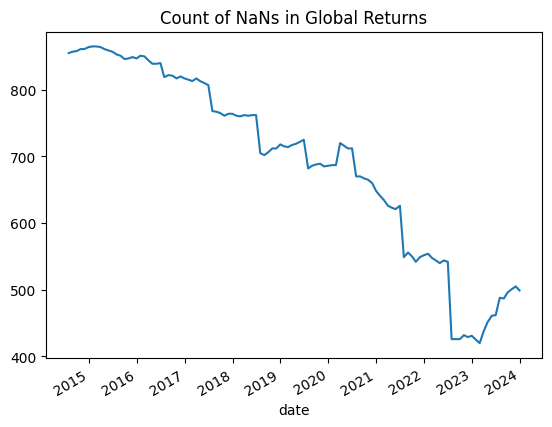

In [300]:
global_returns.isna().sum(axis=1).plot(title="Count of NaNs in Global Returns")

#### 3.1 Univariate sorting

In [301]:
# Memory pre-allocation for template
if take_extremes:
    univariate_sorting_template = pd.DataFrame({f"p_{i}" : np.nan for i in range(1, 4)}, index=global_signal_1.index)
else:
    univariate_sorting_template = pd.DataFrame({f"p_{i}" : np.nan for i in range(1, no_simple_quantiles+1)}, index=global_signal_1.index)

univariate_sorting_template.iloc[first_conditioning_set+1:, :] = 0.0

# Initialise simple_quantiles
signal_0_simple_quantiles = univariate_sorting_template.copy()
signal_1_simple_quantiles = univariate_sorting_template.copy()
signal_2_simple_quantiles = univariate_sorting_template.copy()
# emissions_simple_quantiles = univariate_sorting_template.copy()
# esg_simple_quantiles = univariate_sorting_template.copy()
# ros_beta_simple_quantiles = univariate_sorting_template.copy()
# combined_signal_max_min_simple_quantiles = univariate_sorting_template.copy()

# Initialise simple_quantiles constituents containers
signal_0_simple_quantiles_constituents = []
signal_1_simple_quantiles_constituents = []
signal_2_simple_quantiles_constituents = []
# emissions_simple_quantiles_constituents = []
# esg_simple_quantiles_constituents = []
# ros_beta_simple_quantiles_constituents = []
# combined_signal_max_min_simple_quantiles_constituents = []

# Loop over time periods
for i in range(first_conditioning_set, global_signal_1.shape[0]-1):
    
    # Current and following points in time
    current_signal_0 = global_signal_0.iloc[i, :]
    current_signal_1 = global_signal_1.iloc[i, :]
    current_signal_2 = global_signal_2.iloc[i, :]
    #current_emissions = global_emissions.iloc[i, :]
    #current_esg = global_esg.iloc[i, :]
    #current_ros_beta = global_ros_beta.iloc[i, :]
    current_combined_signal_max_min = global_combined_signal_max_min.iloc[i, :]
    next_ret = global_returns.iloc[i+1, :]

    # Deciles for current point in time
    current_signal_0_simple_quantiles = univariate_portfolio_sorting(current_signal_0, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    current_signal_1_simple_quantiles = univariate_portfolio_sorting(current_signal_1, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    current_signal_2_simple_quantiles = univariate_portfolio_sorting(current_signal_2, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_emissions_simple_quantiles = univariate_portfolio_sorting(current_emissions, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_esg_simple_quantiles = univariate_portfolio_sorting(current_esg, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_ros_beta_simple_quantiles = univariate_portfolio_sorting(current_ros_beta, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_combined_signal_max_min_simple_quantiles = univariate_portfolio_sorting(current_combined_signal_max_min, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)

    # Update univariate sorting returns containers
    for col in current_signal_0_simple_quantiles.index:
        signal_0_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_0_simple_quantiles[col]].mean()
        signal_1_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_1_simple_quantiles[col]].mean()
        signal_2_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_2_simple_quantiles[col]].mean()
        #emissions_simple_quantiles.iloc[i+1][col] += next_ret[current_emissions_simple_quantiles[col]].mean()
        #esg_simple_quantiles.iloc[i+1][col] += next_ret[current_esg_simple_quantiles[col]].mean()
        #ros_beta_simple_quantiles.iloc[i+1][col] += next_ret[current_ros_beta_simple_quantiles[col]].mean()
        #combined_signal_max_min_simple_quantiles.iloc[i+1][col] += next_ret[current_combined_signal_max_min_simple_quantiles[col]].mean()
    
    # Update univariate sorting constituents containers
    signal_0_simple_quantiles_constituents.append(current_signal_0_simple_quantiles)
    signal_1_simple_quantiles_constituents.append(current_signal_1_simple_quantiles)
    signal_2_simple_quantiles_constituents.append(current_signal_2_simple_quantiles)
    #emissions_simple_quantiles_constituents.append(current_emissions_simple_quantiles)
    #esg_simple_quantiles_constituents.append(current_esg_simple_quantiles)
    #ros_beta_simple_quantiles_constituents.append(current_ros_beta_simple_quantiles)
    #combined_signal_max_min_simple_quantiles_constituents.append(current_combined_signal_max_min_simple_quantiles)

What is in the portfolio 

<Axes: title={'center': 'Total Stocks without NAN - Split into 6 Portfolios'}>

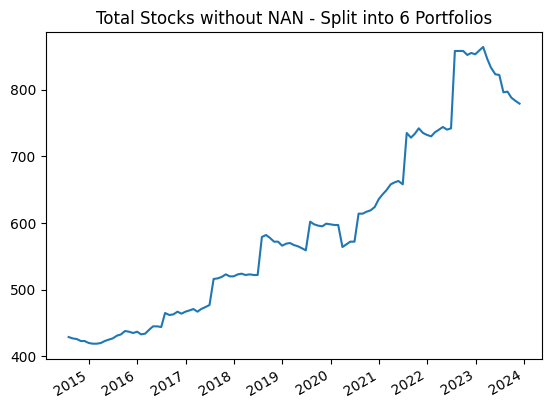

In [302]:
# 1. Calculate the sum of lengths for each month in the list
total_counts = pd.Series({
    month.name: month.apply(len).sum() 
    for month in signal_2_simple_quantiles_constituents
})

# 2. Plot the result
total_counts.plot(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")

Add MSCI

In [303]:
MSCI = pd.read_excel("./data/MSCI/MSCI_World.xlsx", index_col= "Date")
MSCI["return"] = MSCI["MSCI_price"].pct_change()
MSCI.index = pd.to_datetime(MSCI.index)


#Intesrect the same dates:>

# Intersect on year-month (month-end day can differ from signal_0_simple_quantiles)
ym_msci = MSCI.index.to_period("M")
ym_sig = signal_0_simple_quantiles.index.to_period("M")
common_ym = ym_msci.unique().intersection(ym_sig.unique())

MSCI = MSCI[ym_msci.isin(common_ym)].sort_index()
# One row per month when MSCI is higher-frequency (last observation in each month)
MSCI = MSCI.groupby(MSCI.index.to_period("M"), sort=True).last()
MSCI.index = signal_0_simple_quantiles.index

Excess returns with risk free rate

In [304]:
# Transform in excess returns
signal_0_simple_quantiles = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_1_simple_quantiles = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_2_simple_quantiles = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)
MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

In [305]:
def set_first_row_to_zero(df: pd.DataFrame, inplace: bool = False) -> pd.DataFrame:
    out = df if inplace else df.copy()
    out.iloc[0, :] = 0
    return out

In [306]:
global_returns = set_first_row_to_zero(global_returns)
signal_0_simple_quantiles = set_first_row_to_zero(signal_0_simple_quantiles)
signal_1_simple_quantiles = set_first_row_to_zero(signal_1_simple_quantiles)
signal_2_simple_quantiles = set_first_row_to_zero(signal_2_simple_quantiles)
MSCI_excess_returns.iloc[0] = 0

# 6. Sector Split

In [307]:
returns_long = (
    global_returns
      .stack(dropna=True)
      .rename("tr")
      .reset_index()
)
industry_map = (
    global_universe[["date", "gvkey_iid", "Industry"]]
      .drop_duplicates()
)
ret_with_ind = returns_long.merge(industry_map, on=["date", "gvkey_iid"], how="left")
counts_by_industry = (
    ret_with_ind
      .groupby(["date", "Industry"], dropna=False)["gvkey_iid"]
      .nunique()
      .rename("n_stocks_non_nan_return")
      .reset_index()
)
counts_wide = counts_by_industry.pivot(
    index="date", columns="Industry", values="n_stocks_non_nan_return"
)


In [308]:

#portfoliio
counts_wide.describe().round(1)

Industry,NaN,Consumer,Financial,Health Care,ICT,Industrials,Primary Industries,Utilities
count,1.0,114.0,114.0,114.0,114.0,114.0,114.0,114.0
mean,854.0,109.7,99.2,47.5,79.4,114.1,97.1,45.0
std,NaN,18.2,31.3,9.1,21.6,35.6,20.6,6.4
min,854.0,81.0,58.0,34.0,48.0,77.0,67.0,36.0
25%,854.0,97.2,69.0,37.0,62.0,84.0,80.0,39.2
50%,854.0,108.0,97.5,48.0,72.0,97.0,89.5,45.0
75%,854.0,125.5,126.8,54.0,103.0,153.0,112.0,49.0
max,854.0,147.0,161.0,62.0,120.0,190.0,139.0,62.0


In [309]:
lc["Industry"].value_counts()

Industry
Consumer              11080
Industrials           10806
Primary Industries     8623
ICT                    6958
Financial              5946
Health Care            3765
Utilities              2105
Name: count, dtype: int64

In [310]:


DEFAULT_INDUSTRY_COUNTS = {
    "Consumer": even_split_no,
    "Financial": even_split_no,
    "Health Care": even_split_no,
    "ICT": even_split_no,
    "Industrials": even_split_no,
    "Primary Industries": even_split_no,
    "Utilities": even_split_no,
}

def top_x_by_industry(
    signal_row: pd.Series,
    industry_row: pd.Series,
    n_by_industry: dict | None = None,
    *,
    keep_industries: list[str] | None = None,
    ascending: bool = False,
) -> pd.Series:
    """
    Select top X tickers per industry for a single date.

    Parameters
    ----------
    signal_row : pd.Series
        Index = gvkey_iid, values = signal at one date (e.g., global_signal_2.iloc[i, :]).
    industry_row : pd.Series
        Index = gvkey_iid, values = Industry for the same date (aligned to signal_row.index).
    n_by_industry : dict
        Mapping Industry -> number of stocks to select. Defaults to DEFAULT_INDUSTRY_COUNTS.
    keep_industries : list[str]
        If provided, only these industries are processed (others ignored).
    ascending : bool
        False = pick largest signal (top). True = pick smallest (bottom).

    Returns
    -------
    pd.Series
        Index = industries, values = pd.Index of selected gvkey_iid for that industry.
        (Same “shape” idea as your quantile output: a container of constituents.)
    """
    if n_by_industry is None:
        n_by_industry = DEFAULT_INDUSTRY_COUNTS

    # Align & drop rows missing either signal or industry
    df = pd.DataFrame({"signal": signal_row, "Industry": industry_row}).dropna(subset=["signal", "Industry"])

    if keep_industries is not None:
        df = df[df["Industry"].isin(keep_industries)]

    out = pd.Series(dtype=object)

    # Process each industry separately
    for ind, g in df.groupby("Industry"):
        n = int(n_by_industry.get(ind, 0))
        if n <= 0:
            out.loc[ind] = pd.Index([], dtype=object)
            continue

        chosen = g.sort_values("signal", ascending=ascending).head(n).index
        out.loc[ind] = pd.Index(chosen)

    return out

Build an industry pivot aligned to global_returns / global_signal_*

In [311]:
global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

Store constituents over time + compute “next-month return” by Industry

In [312]:

industries = list[str](DEFAULT_INDUSTRY_COUNTS.keys())
industry_returns = pd.DataFrame(index=global_returns.index, columns=industries, dtype=float)
industry_returns.iloc[first_conditioning_set+1:, :] = 0.0

# Store constituents each period (this is your “variable that stores stocks selected each point in time”)
industry_constituents_over_time = []

for i in range(first_conditioning_set, global_returns.shape[0] - 1):
    date = global_returns.index[i]
    current_signal = global_signal_2.iloc[i, :]     # or signal_0/signal_1/combined
    current_industry = global_industry.iloc[i, :]
    next_ret = global_returns.iloc[i+1, :]

    selected = top_x_by_industry(
        signal_row=current_signal,
        industry_row=current_industry,
        n_by_industry=DEFAULT_INDUSTRY_COUNTS,  # can pass a custom dict here
        ascending=False,
    )

    # Save constituents for this date
    industry_constituents_over_time.append(selected)

    # Update industry return series (mean next-month return of selected stocks in each industry)
    for ind in selected.index:
        tickers = selected[ind]
        industry_returns.iloc[i+1, industry_returns.columns.get_loc(ind)] += next_ret[tickers].mean()
    
    selected.name = date   

# Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!

In [313]:
industry_returns

,Consumer,Financial,Health Care,ICT,Industrials,Primary Industries,Utilities
date,,,,,,,
2014-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-08-29,0.029649,0.009969,0.023899,0.026990,0.017634,0.007260,0.017548
2014-09-30,-0.040447,-0.019563,-0.026585,-0.031870,-0.050862,-0.042805,-0.037871
2014-10-31,0.035212,-0.006274,0.027178,-0.011815,-0.041402,-0.059517,0.045678
2014-11-28,0.054806,0.021083,0.039809,0.040851,0.003344,0.020230,0.006697
...,...,...,...,...,...,...,...
2023-08-31,-0.036107,-0.001765,-0.021595,-0.040070,-0.002270,-0.014019,-0.054585
2023-09-29,-0.051658,-0.038559,-0.098574,-0.037885,-0.060645,-0.055925,-0.043695
2023-10-31,-0.080145,-0.022313,-0.066003,-0.028809,-0.052532,-0.047409,0.000060


In [314]:
sector_portfolio_returns = industry_returns.mean(axis=1)

rfrate

In [315]:
sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)

# replace nan with 0 to ensure first element matches
sector_portfolio_returns.iloc[0] = 0


# Cumulative Plot

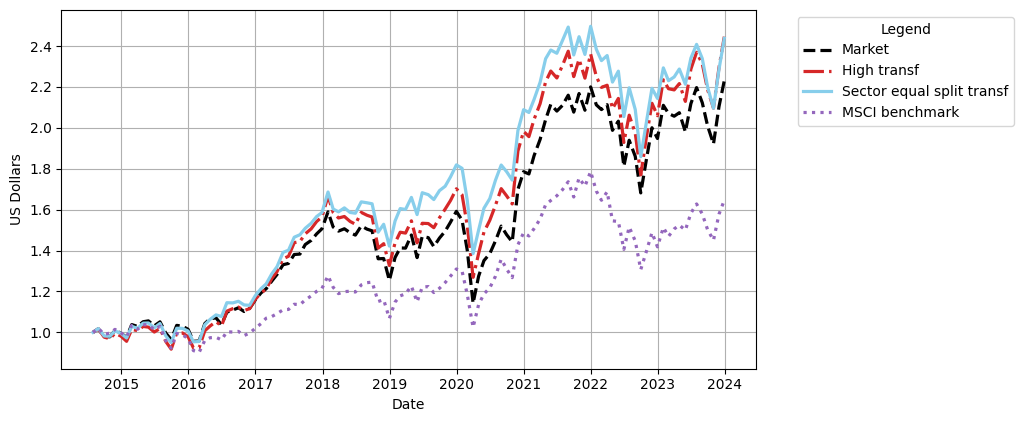

In [316]:
from matplotlib.cm import get_cmap

# Plotting data
global_gross_portfolio_returns = pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1+global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)
global_gross_portfolio_returns['High transf']  = 1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
global_gross_portfolio_returns["Sector equal split transf"] =  1 + sector_portfolio_returns
global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

# Compute the cumulative product starting from 1
cumulative_products = global_gross_portfolio_returns.cumprod()

# Plotting
fig, ax = plt.subplots()
colors = ['black','#d62728','#87CEEB','#9467bd', '#ADD8E6'  ]


line_styles = ['--', '-.', '-', ':']#, (0, (3, 5, 1, 5))]
#line_styles = '-'
for i, col in enumerate(cumulative_products.columns):
    ax.plot(cumulative_products.index, cumulative_products[col], label=col, color=colors[i],linewidth=2.3, linestyle=line_styles[i])

ax.set_xlabel('Date')
ax.set_ylabel('US Dollars')
ax.grid(True)

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./output/img/cumulative_returns_' + res_suffix + '.png', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# 5. Fama-French

In [317]:
sector_portfolio_returns_df = pd.DataFrame()
sector_portfolio_returns_df["Sector equal split transf"] = sector_portfolio_returns
sector_portfolio_returns = sector_portfolio_returns_df

In [318]:
from functions.fama_french import ff3_regressions

# Table on FF3
ff3_parts = [
    low_high(ff3_regressions(signal_0_simple_quantiles, fama_french.reset_index(drop=True)), 'pdvocacy'),
    low_high(ff3_regressions(signal_1_simple_quantiles, fama_french.reset_index(drop=True)), 'Prep'),
    low_high(ff3_regressions(signal_2_simple_quantiles, fama_french.reset_index(drop=True)), 'transf'),
    ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True))
]

# if esg_choice != 'none':
#     ff3_parts += [
#         low_high(ff3_regressions(esg_simple_quantiles, fama_french.reset_index(drop=True)), 'ESG'),
#         low_high(ff3_regressions(signal_2_minus_esg_simple_quantiles, fama_french.reset_index(drop=True)), 'Signal2MinusESG'),
#         low_high(ff3_regressions(esg_signal_2_quantiles, fama_french.reset_index(drop=True)), 'ESGxTransf'),
#     ]

# ff3_parts += [
#     low_high(ff3_regressions(combined_signal_max_min_simple_quantiles, fama_french.reset_index(drop=True)), 'Combined'),
# ]

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
ff3_parts_df.to_csv('./output/ff3_' + res_suffix + '.csv')

# # Table on downside risk
# risk_parts = [
#     low_high(risk((1 + signal_0_simple_quantiles).cumprod()).T, 'Advocacy'),
#     low_high(risk((1 + signal_1_simple_quantiles).cumprod()).T, 'Prep'),
#     low_high(risk((1 + signal_2_simple_quantiles).cumprod()).T, 'Transf'),
# ]

# if esg_choice != 'none':
#     risk_parts += [
#         low_high(risk((1 + esg_simple_quantiles).cumprod()).T, 'ESG'),
#         low_high(risk((1 + signal_2_minus_esg_simple_quantiles).cumprod()).T, 'Signal2MinusESG'),
#         low_high(risk((1 + esg_signal_2_quantiles).cumprod()).T, 'ESGxTransf'),
#     ]

# market_risk = risk(pd.DataFrame(1 + mkt_returns).cumprod()).T
# market_risk.columns = ['Market']

# risk_parts += [
#     low_high(risk((1 + ros_beta_simple_quantiles).cumprod()).T, 'RosBeta'),
#     low_high(risk((1 + combined_signal_max_min_simple_quantiles).cumprod()).T, 'Combined'),
#     market_risk,
# ]

# risk_parts_df = pd.concat(risk_parts, axis=1).round(2)
# risk_parts_df.to_csv('./tables/risk_' + res_suffix + '.csv')

In [319]:
ff3_parts_df

,Low pdvocacy,High pdvocacy,Low Prep,High Prep,Low transf,High transf,Sector equal split transf
alpha,0.13,0.19,0.23,0.00,0.14,0.24,0.24
beta_mkt,1.12,1.13,1.09,1.14,1.12,1.10,1.04
beta_smb,0.07,0.18,0.13,0.15,0.15,0.03,0.01
beta_hml,0.21,0.24,0.18,0.22,0.23,0.19,0.12
p-value(alpha),0.17,0.05,0.02,0.97,0.16,0.02,0.02
p-value(beta_mkt),0.00,0.00,0.00,0.00,0.00,0.00,0.00
p-value(beta_smb),0.25,0.01,0.03,0.02,0.02,0.66,0.92
p-value(beta_hml),0.00,0.00,0.00,0.00,0.00,0.00,0.00
Adj. R^2,0.96,0.96,0.96,0.96,0.96,0.95,0.95


# Rolling Alpha

In [320]:
window_size = 40

from functions.fama_french import rolling_ff3_alphas

# Compute rolling alphas for the core signals (sector-split will be appended later
# once `sector_portfolio_returns` has been created).
_alpha_col = f"p_{no_simple_quantiles}"

_sector_label = "Sector equal split transf"

rolling_alphas = rolling_ff3_alphas(
    signals=[
        {
            "label": "High transf",
            "returns": signal_2_simple_quantiles,
            "alpha_column": _alpha_col,
        },
        {
            "label": _sector_label,
            "returns": sector_portfolio_returns,
            "alpha_column": _sector_label,
        },
    ],
    fama_french=fama_french,
    window_size=window_size,
)

pd.DataFrame(rolling_alphas).head()

,High transf,Sector equal split transf
date,,
2017-10-31,0.424578,0.492113
2017-11-30,0.357854,0.428962
2017-12-29,0.366445,0.430080
2018-01-31,0.413278,0.478653
2018-02-28,0.431761,0.467686


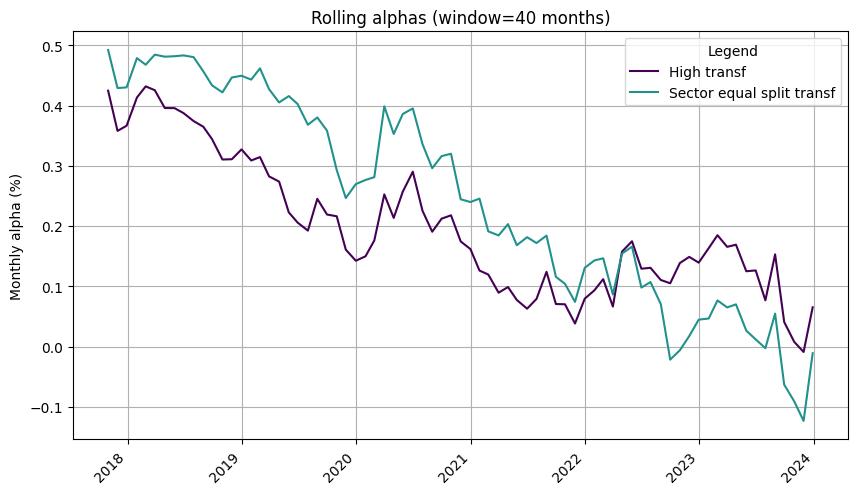

<Axes: title={'center': 'Rolling alphas (window=40 months)'}, ylabel='Monthly alpha (%)'>

In [321]:
from functions.fama_french import plot_rolling_alpha_function

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title="Rolling alphas (window=40 months)",
    save_path="./output/img/rolling_alphas_" + res_suffix + ".png",
)

# 8. More Performance Metrics

Plan:

1 - Cum returns table
2 - Sector and Region Split

Cum returns net of riskfree rate

In [322]:
portfolio_returns = global_gross_portfolio_returns - 1

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,6.06%,11.05%,14.55%,14.55%,24.96%,77.98%,123.14%,123.14%
High transf,6.60%,11.82%,18.74%,18.74%,23.34%,84.28%,144.56%,144.56%
Sector equal split transf,6.64%,10.83%,13.70%,13.70%,16.69%,71.42%,143.74%,143.74%
MSCI benchmark,4.38%,9.64%,16.10%,16.10%,10.74%,54.13%,64.67%,64.67%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.57,-10.69%,-28.25%,,
High transf,0.64,-10.31%,-25.47%,0.24,0.020
Sector equal split transf,0.66,-10.88%,-25.54%,0.24,0.020
MSCI benchmark,0.42,-9.55%,-26.82%,,


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

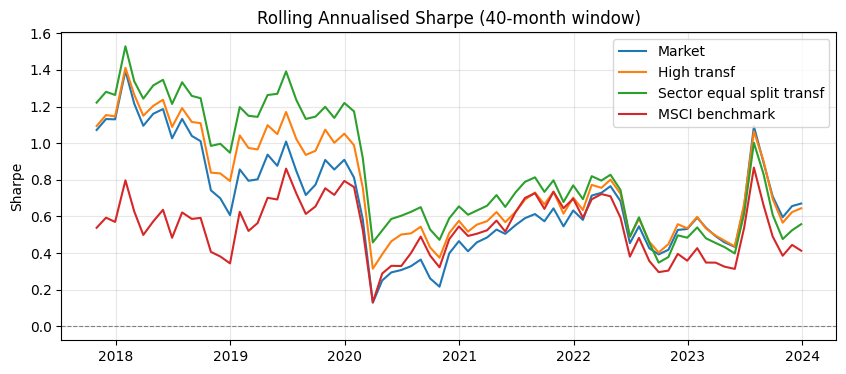

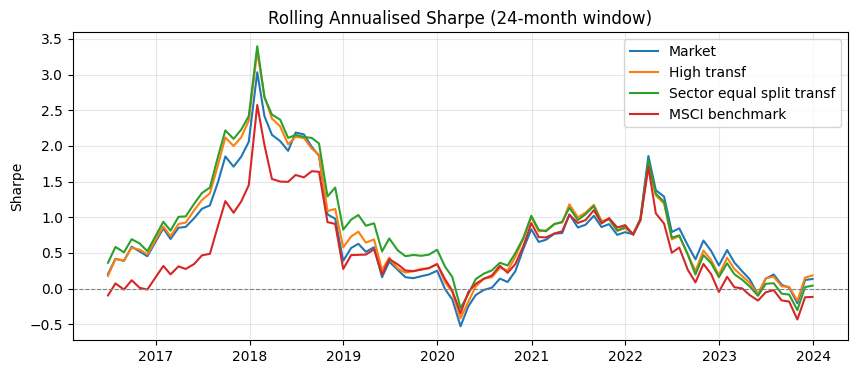

In [323]:
from functions.Strategy_Perfomance import StrategyPerformance

start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/strategy_cumulative_performance_{start_date}-{end_date}.csv"
)
display(cumulative_table)

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/strategy_performance_metrics_{start_date}-{end_date}.csv"
)
display(risk_table)

sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/strategy_rolling_sharpe_40m_{start_date}-{end_date}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/strategy_rolling_sharpe_24m_{start_date}-{end_date}.png")


# Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


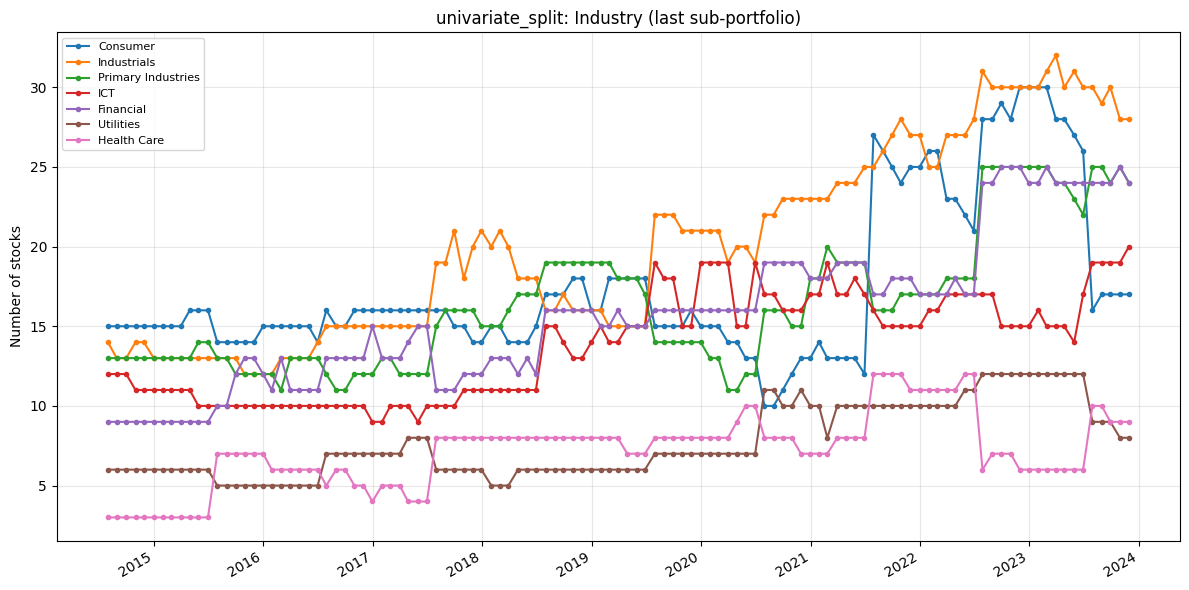

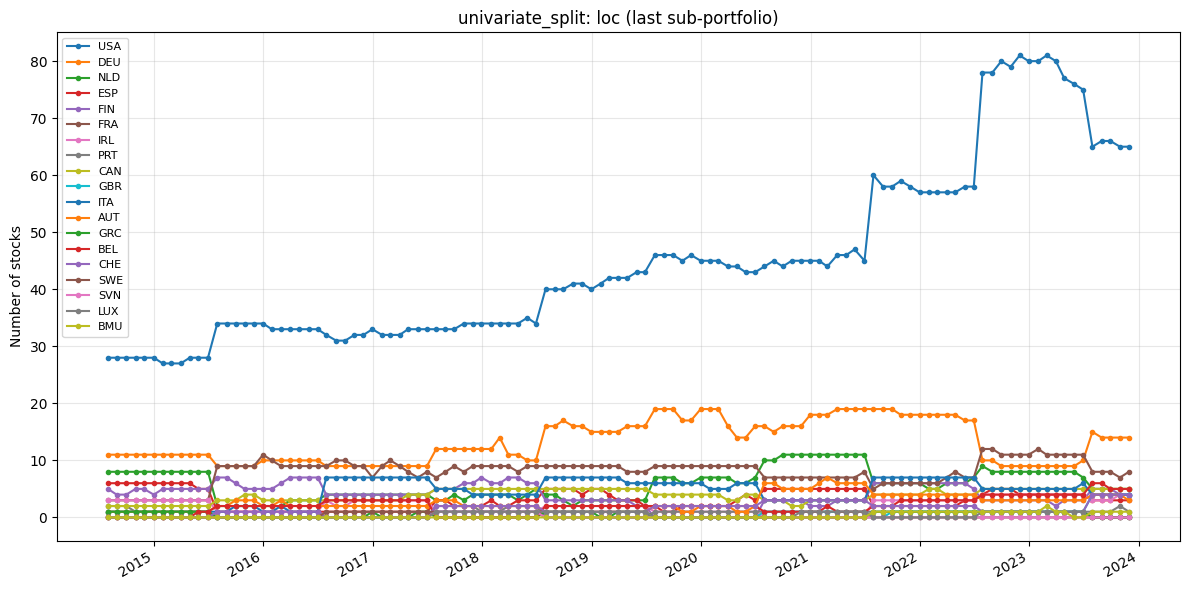

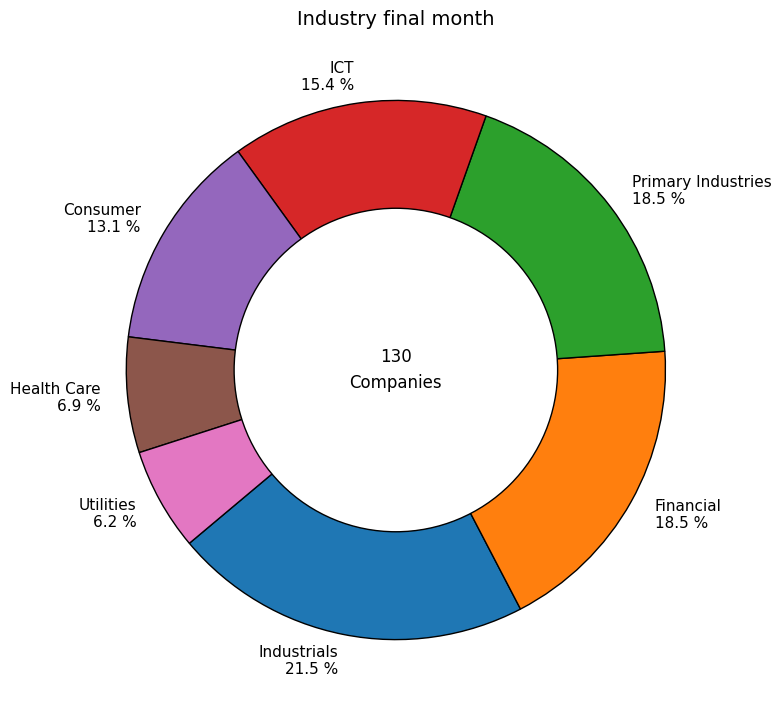

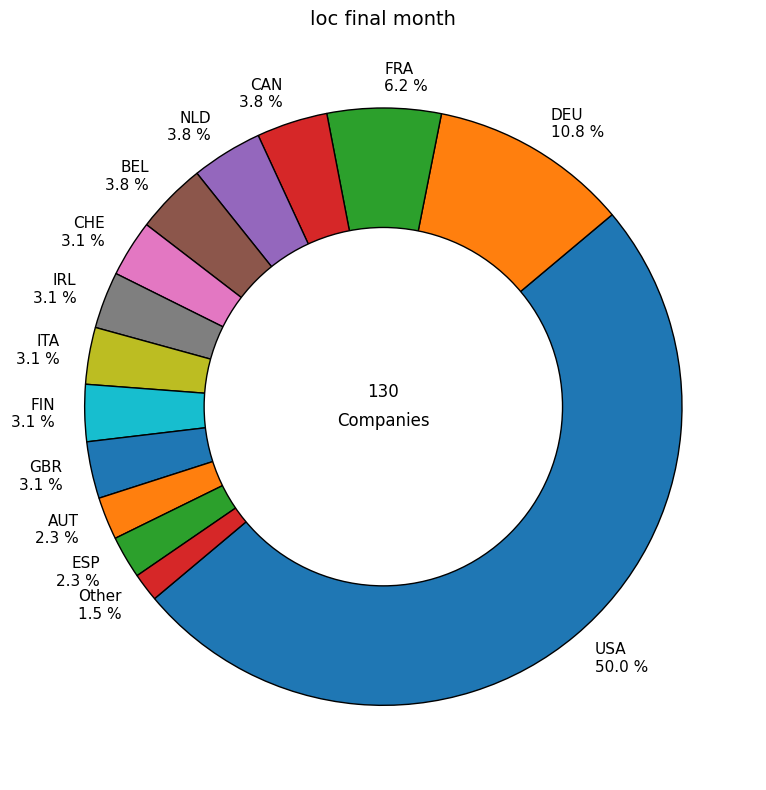

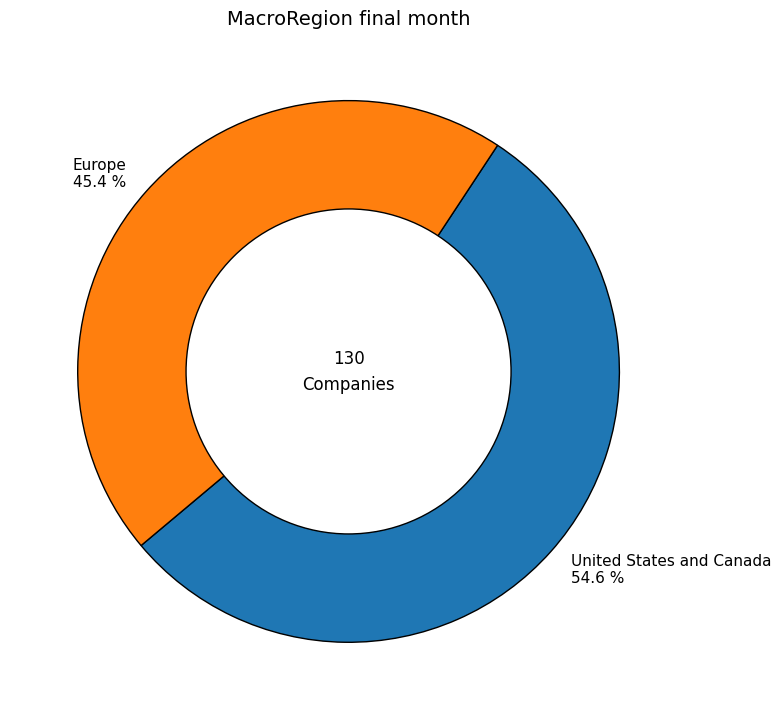

{'category_over_time': {'Industry': <Figure size 1200x600 with 1 Axes>,
  'loc': <Figure size 1200x600 with 1 Axes>},
 'pie': {'Industry': <Figure size 800x800 with 1 Axes>,
  'loc': <Figure size 800x800 with 1 Axes>,
  'MacroRegion': <Figure size 800x800 with 1 Axes>}}

In [324]:
from IPython.display import display
from functions.Portfolio_Constituents import PortfolioConstituents

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
#pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)